<a href="https://colab.research.google.com/github/cedrick8sangwa/Metallurgy-data-analytics/blob/main/Jaw_Crusher_%26_vibrating_sreen_Optimization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

=== IMPORTANCE DES VARIABLES SUR LA PUISSANCE (kW) ===
    Feature  Importance (%)
Tonnage_tph       53.052756
      CS_mm       27.457643
  Wi_kWh_st       19.489602

=== IMPORTANCE DES VARIABLES SUR LE P80 (mm) ===
    Feature  Importance (%)
      CS_mm       98.801406
  Wi_kWh_st        0.616510
Tonnage_tph        0.582084


/tmp/ipykernel_3021/1101324604.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance (%)', y='Feature', data=importances_power, palette='Blues_r')
/tmp/ipykernel_3021/1101324604.py:63: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance (%)', y='Feature', data=importances_p80, palette='Greens_r')


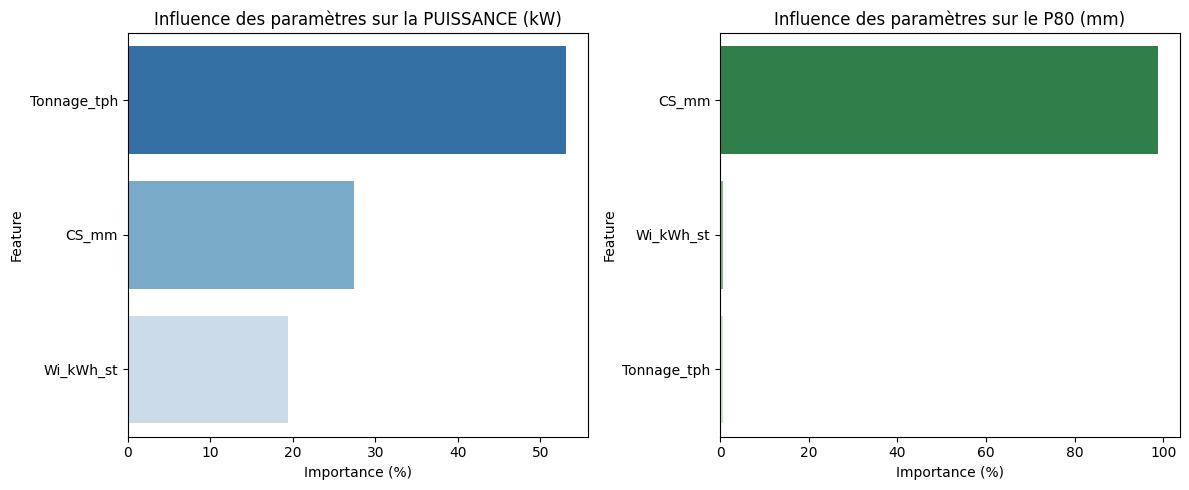

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor

# 1. Chargement des données d'essais MetSim
data = {
    'CS_mm': [50, 100, 50, 100, 50, 100, 50, 100, 75],
    'Tonnage_tph': [300, 300, 700, 700, 300, 300, 700, 700, 500],
    'Wi_kWh_st': [10, 10, 10, 10, 15, 15, 15, 15, 12.5],
    'P80_mm': [35.9, 61.5, 35.9, 61.5, 35.9, 61.5, 35.9, 61.5, 75.0],
    'Power_kW': [81.55, 46.102, 190.24, 107.57, 122.33, 69.15, 285.44, 161.35, 132.13],
    'Specific_Energy_kWh_t': [0.2718, 0.1537, 0.2718, 0.1537, 0.4078, 0.2305, 0.4078, 0.2305, 0.2643]
}

df = pd.DataFrame(data)

# Variables explicatives (Features)
X = df[['CS_mm', 'Tonnage_tph', 'Wi_kWh_st']]

# Targets (Sorties à prédire)
y_power = df['Power_kW']
y_p80 = df['P80_mm']

# --- MODEL 1: RANDOM FOREST POUR LA PUISSANCE (kW) ---
rf_power = RandomForestRegressor(n_estimators=100, random_state=42)
rf_power.fit(X, y_power)

# Feature Importance Puissance
importances_power = pd.DataFrame({
    'Feature': X.columns,
    'Importance (%)': rf_power.feature_importances_ * 100
}).sort_values(by='Importance (%)', ascending=False)

# --- MODEL 2: RANDOM FOREST POUR LE P80 (mm) ---
rf_p80 = RandomForestRegressor(n_estimators=100, random_state=42)
rf_p80.fit(X, y_p80)

importances_p80 = pd.DataFrame({
    'Feature': X.columns,
    'Importance (%)': rf_p80.feature_importances_ * 100
}).sort_values(by='Importance (%)', ascending=False)

# --- AFFICHAGE DES RÉSULTATS DANS LA CONSOLE ---
print("=== IMPORTANCE DES VARIABLES SUR LA PUISSANCE (kW) ===")
print(importances_power.to_string(index=False))

print("\n=== IMPORTANCE DES VARIABLES SUR LE P80 (mm) ===")
print(importances_p80.to_string(index=False))

# --- GRAPHIQUES FEATURE IMPORTANCE ---
plt.figure(figsize=(12, 5))

# Graphique Puissance
plt.subplot(1, 2, 1)
sns.barplot(x='Importance (%)', y='Feature', data=importances_power, palette='Blues_r')
plt.title('Influence des paramètres sur la PUISSANCE (kW)')
plt.xlabel('Importance (%)')

# Graphique P80
plt.subplot(1, 2, 2)
sns.barplot(x='Importance (%)', y='Feature', data=importances_p80, palette='Greens_r')
plt.title('Influence des paramètres sur le P80 (mm)')
plt.xlabel('Importance (%)')

plt.tight_layout()
plt.savefig('feature_importance_crusher.png', dpi=300)
plt.show()